# Focus - Exploratory Data Analysis

This notebook will focus on the cleaned portfolio dataset created from the preprocessing.

## Goal
To understand asset performance, volatility, correlations, return distributions, and drawdowns before building models or portfolio optimizing strategies

# Imports

In [23]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Visual Settings

In [24]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.style.use("seaborn-v0_8")

# Load Processed Data

In [25]:
PROCESSED_DATA_PATH = Path('../data/processed/')

In [26]:
adj_close = pd.read_csv(
    PROCESSED_DATA_PATH / "adjusted_close_clean.csv",
    index_col=0,
    parse_dates=True
)

In [27]:
daily_returns = pd.read_csv(
    PROCESSED_DATA_PATH / "daily_returns_clean.csv",
    index_col=0,
    parse_dates=True
)

In [28]:
summary_stats = pd.read_csv(
    PROCESSED_DATA_PATH / "processed_summary_stats.csv",
    index_col=0
)

# Inspect Data

In [29]:
adj_close.head()

,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267075,85.561783,59.450500,131.293884,125.150002,85.901276,35.024227,74.897774,254.261215,78.699905,31.334095,72.280708,150.057236,235.954300,98.705627,191.993912,107.888237,59.645279,44.600658,33.712952,58.185497
2018-01-03,40.260063,85.569626,60.209999,131.494553,124.820000,85.988815,34.947304,75.304634,256.392456,79.066170,30.669386,72.192986,151.515305,237.446747,99.177605,194.007919,108.962318,59.472107,44.911564,33.020184,59.328266
2018-01-04,40.447071,85.514771,60.479500,133.300446,125.459999,87.220642,35.439533,75.640739,260.790466,79.762070,30.511806,72.703331,151.780426,238.447525,99.161896,194.850037,109.367455,58.447601,45.284664,33.127247,59.410378
2018-01-05,40.907574,85.459908,61.457001,135.407318,125.330002,86.660713,35.431839,76.569427,263.153290,80.750969,30.651201,72.751160,153.304764,240.036575,98.878716,198.565567,111.986679,58.476479,45.587799,33.051662,59.362473
2018-01-08,40.755634,85.436386,62.343498,138.810043,125.309998,86.788712,35.378010,76.180275,261.940094,80.833374,30.903748,73.133881,153.901230,240.475525,98.815811,195.119141,112.438934,58.779476,45.564495,32.994995,59.629349


In [30]:
daily_returns.head()

,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,-0.000174,0.000092,0.012775,0.001528,-0.002637,0.001019,-0.002196,0.005432,0.008382,0.004654,-0.021214,-0.001214,0.009717,0.006325,0.004782,0.010490,0.009956,-0.002903,0.006971,-0.020549,0.019640
2018-01-04,0.004645,-0.000641,0.004476,0.013734,0.005127,0.014325,0.014085,0.004463,0.017153,0.008801,-0.005138,0.007069,0.001750,0.004215,-0.000158,0.004341,0.003718,-0.017227,0.008307,0.003242,0.001384
2018-01-05,0.011385,-0.000642,0.016163,0.015805,-0.001036,-0.006420,-0.000217,0.012278,0.009060,0.012398,0.004569,0.000658,0.010043,0.006664,-0.002856,0.019069,0.023949,0.000494,0.006694,-0.002282,-0.000806
2018-01-08,-0.003714,-0.000275,0.014425,0.025130,-0.000160,0.001477,-0.001519,-0.005082,-0.004610,0.001020,0.008239,0.005261,0.003891,0.001829,-0.000636,-0.017357,0.004038,0.005182,-0.000511,-0.001715,0.004496
2018-01-09,-0.000115,-0.002752,0.004676,0.002409,-0.004628,0.005069,0.005000,-0.000813,0.007160,-0.000679,-0.007322,-0.007305,0.000061,0.002263,-0.013373,0.004983,-0.001927,-0.012888,0.000853,-0.003668,-0.004246


In [31]:
summary_stats

,mean_daily_return,daily_volatility,annualized_return,annualized_volatility,min_daily_return,max_daily_return
AAPL,0.001140,0.019401,0.287326,0.307982,-0.128647,0.153289
AGG,0.000077,0.003669,0.019346,0.058242,-0.040010,0.023721
AMZN,0.000914,0.021680,0.230284,0.344154,-0.140494,0.135359
CAT,0.000936,0.020035,0.235961,0.318047,-0.142822,0.116346
GLD,0.000623,0.009535,0.156912,0.151369,-0.064269,0.048530
JPM,0.000822,0.018298,0.207217,0.290465,-0.149649,0.180125
KO,0.000413,0.012163,0.104066,0.193087,-0.096725,0.064796
LLY,0.001520,0.019741,0.383132,0.313381,-0.141364,0.156798
LMT,0.000442,0.015659,0.111428,0.248579,-0.127616,0.107279
MSFT,0.001065,0.017861,0.268446,0.283531,-0.147390,0.142169


In [32]:
# Extra Info 
print("Adjusted close shape:", adj_close.shape)
print("Daily returns shape:", daily_returns.shape)
print("Start date:", adj_close.index.min())
print("End date:", adj_close.index.max())

Adjusted close shape: (2010, 21)
Daily returns shape: (2009, 21)
Start date: 2018-01-02 00:00:00
End date: 2025-12-30 00:00:00


# Separate Portfolio Assets and Benchmark
The processed dataset includes daily adjusted close prices and daily returns for the selected assets. SPY is included as a benchmark for comparison.

In [33]:
BENCHMARK = "SPY"

In [34]:
portfolio_assets = [ticker for ticker in adj_close.columns if ticker != BENCHMARK]

In [35]:
BENCHMARK in portfolio_assets

False

In [36]:
portfolio_prices = adj_close[portfolio_assets]
benchmark_prices = adj_close[BENCHMARK]

portfolio_returns = daily_returns[portfolio_assets]
benchmark_returns = daily_returns[BENCHMARK]

SPY is separated from the portfolio asset list because it will be used as the benchmark instead of being treated as an optimized portfolio holding.

# Calculate Cumulative Returns

How cumulative returns are calculated are 1 + daily returns.

This is because daily returns are a percentage.

Ex: 
Day 1 return = 10% = 0.1
Day 2 Return = -5% = -0.05
Day 3 Return = 20% = 0.20

So we take this number and add 1 to it (1 + daily returns)

We are turning the return into a growth multiplier.

Ex:
10% return  -> 1 + 0.10  = 1.10
-5% return  -> 1 - 0.05  = 0.95
20% return  -> 1 + 0.20  = 1.20

1.10 = your money became 110% of what it was
0.95 = your money became 95% of what it was
1.20 = your money became 120% of what it was

In [37]:
# .cumprod() == cumulative product == keep multiplying everything up to this point
cumulative_returns = (1 + daily_returns).cumprod()

cumulative_returns.head()

,AAPL,AGG,AMZN,CAT,GLD,JPM,KO,LLY,LMT,MSFT,NEE,PG,QQQ,SPY,TLT,UNH,V,VNQ,VXUS,VZ,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.999826,1.000092,1.012775,1.001528,0.997363,1.001019,0.997804,1.005432,1.008382,1.004654,0.978786,0.998786,1.009717,1.006325,1.004782,1.010490,1.009956,0.997097,1.006971,0.979451,1.019640
2018-01-04,1.004470,0.999451,1.017309,1.015283,1.002477,1.015359,1.011858,1.009920,1.025679,1.013496,0.973757,1.005847,1.011484,1.010567,1.004623,1.014876,1.013711,0.979920,1.015336,0.982627,1.021051
2018-01-05,1.015906,0.998809,1.033751,1.031330,1.001438,1.008841,1.011638,1.022319,1.034972,1.026062,0.978206,1.006509,1.021642,1.017301,1.001754,1.034228,1.037988,0.980404,1.022133,0.980385,1.020228
2018-01-08,1.012133,0.998534,1.048662,1.057247,1.001278,1.010331,1.010101,1.017123,1.030201,1.027109,0.986266,1.011804,1.025617,1.019161,1.001116,1.016278,1.042180,0.985484,1.021610,0.978704,1.024815
2018-01-09,1.012016,0.995787,1.053566,1.059794,0.996644,1.015453,1.015151,1.016297,1.037577,1.026411,0.979044,1.004413,1.025680,1.021468,0.987729,1.021342,1.040171,0.972783,1.022481,0.975114,1.020463


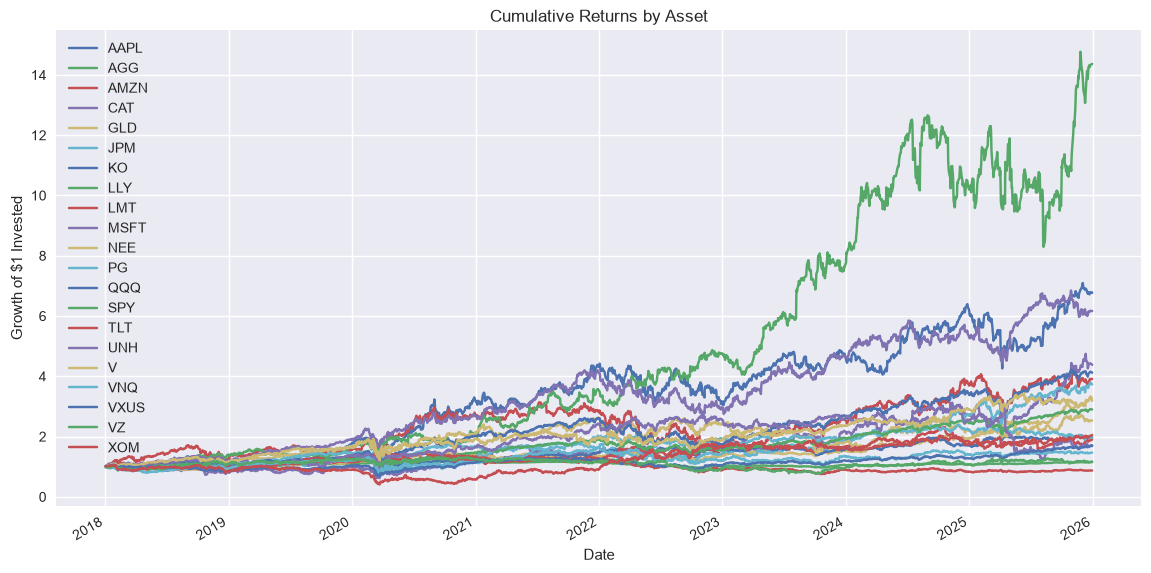

In [38]:
cumulative_returns.plot(figsize=(14, 7), title="Cumulative Returns by Asset")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.show()

This chart shows how $1 invested in each asset would have grown over time. This makes it easier to compare performance across assets with different price levels.

# Portfolio Asset vs Benchmark

In [39]:
portfolio_cumulative_returns = (1 + portfolio_returns).cumprod()
benchmark_cumulative_returns = (1 + benchmark_returns).cumprod()

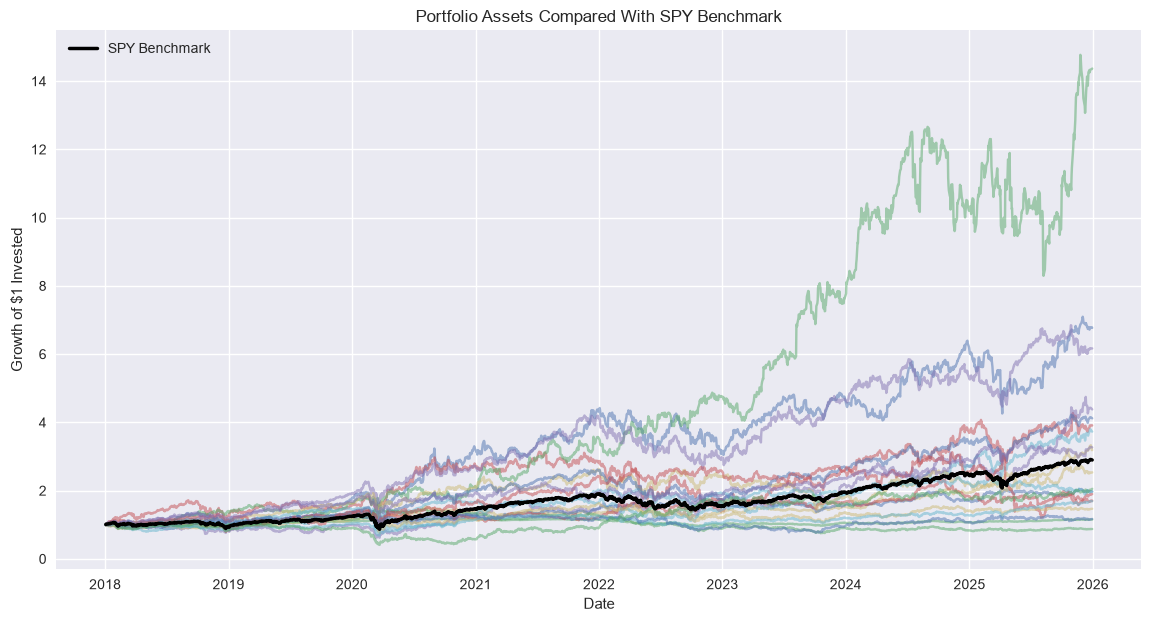

In [ ]:
plt.figure(figsize=(14, 7))

for ticker in portfolio_cumulative_returns.columns:
    plt.plot(portfolio_cumulative_returns.index, portfolio_cumulative_returns[ticker], alpha=0.5)

# label SPY explicitly
plt.plot(
    benchmark_cumulative_returns.index,
    benchmark_cumulative_returns,
    color="black",
    linewidth=2.5,
    label="SPY Benchmark"
)

plt.title("Portfolio Assets Compared With SPY Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.legend()
plt.show()